In [1]:
import matplotlib.pyplot as plt
import ast
import pandas as pd
import numpy as np
import cnn_surgery.utils.metrics as metrics

ModuleNotFoundError: No module named 'cnn_surgery'

In [ ]:
DATASET = 'mnist'
file_path = f'{DATASET}_relative_acc_evaluation.csv'
df = pd.read_csv(file_path)

In [ ]:
len(df)

1800

In [ ]:
# filters
df_filtered = df
df_filtered = df[~df['original_accuracy'].apply(lambda x: 0.0 in ast.literal_eval(x))]
#df_filtered = df_filtered[~df_filtered.apply(lambda row: ast.literal_eval(row['original_accuracy'])[row['target_class']] < 0.9, axis=1)]
#df_filtered = df_filtered[~df_filtered.apply(lambda row: np.mean(ast.literal_eval(row['original_accuracy'])) < 0.7, axis=1)]
#df_filtered = df_filtered[~(df_filtered['distance_travelled'] < 1.0)]
df = df_filtered

In [ ]:
len(df)

1494

In [ ]:
df['target_over_overall'] = df.apply(lambda row: ast.literal_eval(row['accuracy_after'])[row['target_class']], axis=1) / df['overall_accuracy']
df['target_over_overall_rv'] = df.apply(lambda row: ast.literal_eval(row['accuracy_after_rv'])[row['target_class']], axis=1) / df['overall_accuracy_rv']
df['mean_rest_acc'] = df.apply(lambda row: np.mean([x for i,x in enumerate(ast.literal_eval(row['accuracy_after'])) if i != row['target_class']]), axis=1)
df['mean_rest_acc_rv'] = df.apply(lambda row: np.mean([x for i,x in enumerate(ast.literal_eval(row['accuracy_after_rv'])) if i != row['target_class']]), axis=1)
df['avg_retain_accuracy'] = df.apply(lambda row: metrics.avg_retain_accuracy(ast.literal_eval(row['original_accuracy']), ast.literal_eval(row['accuracy_after']), row['target_class'], proportional=True), axis=1)
df['avg_retain_accuracy_rv'] = df.apply(lambda row: metrics.avg_retain_accuracy(ast.literal_eval(row['original_accuracy']), ast.literal_eval(row['accuracy_after_rv']), row['target_class'], proportional=True), axis=1)
# calculate metrics
df['max_difference'] = df.apply(lambda row: metrics.max_difference(ast.literal_eval(row['original_accuracy']), ast.literal_eval(row['accuracy_after']), row['target_class']), axis=1)
df['mean_difference'] = df.apply(lambda row: metrics.mean_difference(ast.literal_eval(row['original_accuracy']), ast.literal_eval(row['accuracy_after']), row['target_class']), axis=1)
df['clipped_negative_mean_difference'] = df.apply(lambda row: metrics.clipped_negative_mean_difference(ast.literal_eval(row['original_accuracy']), ast.literal_eval(row['accuracy_after']), row['target_class']), axis=1)
#df['relative_clipped_negative_mean_difference'] = df.apply(lambda row: metrics.clipped_negative_mean_difference(ast.literal_eval(row['original_accuracy']), ast.literal_eval(row['accuracy_after']), row['target_class'], proportional=True), axis=1)
df['target_difference'] = df.apply(lambda row: metrics.target_difference(ast.literal_eval(row['original_accuracy']), ast.literal_eval(row['accuracy_after']), row['target_class']), axis=1)
df['relative_target_difference'] = df.apply(lambda row: metrics.target_difference(ast.literal_eval(row['original_accuracy']), ast.literal_eval(row['accuracy_after']), row['target_class'], proportional=True), axis=1)
df['relative_target_difference_rv'] = df.apply(lambda row: metrics.target_difference(ast.literal_eval(row['original_accuracy']), ast.literal_eval(row['accuracy_after_rv']), row['target_class'], proportional=True), axis=1)
df['target_accuracy'] = df.apply(lambda row: ast.literal_eval(row['accuracy_after'])[row['target_class']], axis=1)
# metrics for rv
df['max_difference_rv'] = df.apply(lambda row: metrics.max_difference(ast.literal_eval(row['original_accuracy']), ast.literal_eval(row['accuracy_after_rv']), row['target_class']), axis=1)
df['mean_difference_rv'] = df.apply(lambda row: metrics.mean_difference(ast.literal_eval(row['original_accuracy']), ast.literal_eval(row['accuracy_after_rv']), row['target_class']), axis=1)
df['clipped_negative_mean_difference_rv'] = df.apply(lambda row: metrics.clipped_negative_mean_difference(ast.literal_eval(row['original_accuracy']), ast.literal_eval(row['accuracy_after_rv']), row['target_class']), axis=1)
df['target_difference_rv'] = df.apply(lambda row: metrics.target_difference(ast.literal_eval(row['original_accuracy']), ast.literal_eval(row['accuracy_after_rv']), row['target_class']), axis=1)
df['target_accuracy_rv'] = df.apply(lambda row: ast.literal_eval(row['accuracy_after_rv'])[row['target_class']], axis=1)

In [ ]:
df.groupby('stop_threshold')['relative_target_difference'].count()

stop_threshold
0.1    166
0.2    166
0.3    166
0.4    166
0.5    166
0.6    166
0.7    166
0.8    166
0.9    166
Name: relative_target_difference, dtype: int64

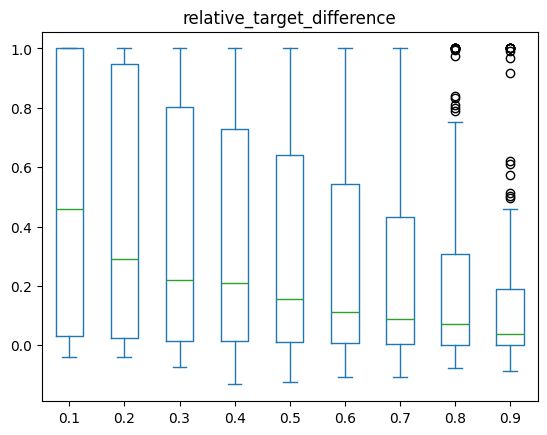

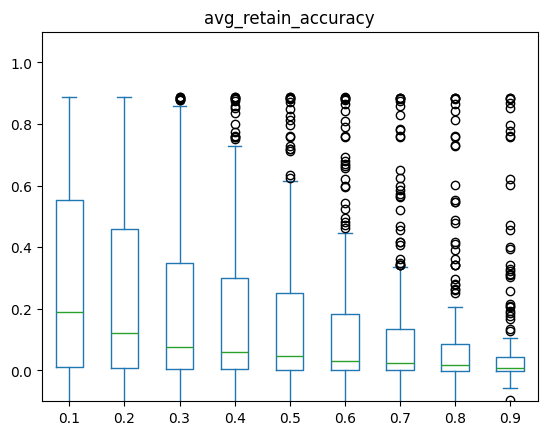

In [ ]:
df.plot.box(column='relative_target_difference', by='stop_threshold')
df.plot.box(column='avg_retain_accuracy', by='stop_threshold', ylim=(-0.1,1.1))

forget = df.groupby('stop_threshold')['relative_target_difference'].median()
retain = df.groupby('stop_threshold')['avg_retain_accuracy'].median()

forget_rv = df.groupby('stop_threshold')['relative_target_difference_rv'].median()
retain_rv = df.groupby('stop_threshold')['avg_retain_accuracy_rv'].median()

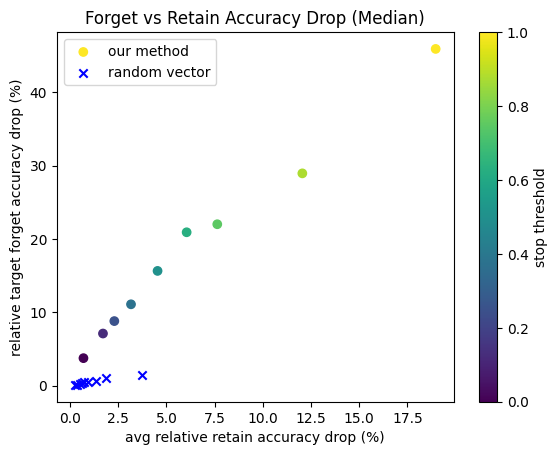

In [ ]:
plt.scatter(retain.values * 100, forget.values * 100, c=1-forget.index, label='our method')
plt.scatter(retain_rv.values * 100, forget_rv.values * 100, c='blue', marker='x', label='random vector')
plt.xlabel('avg relative retain accuracy drop (%)')
plt.ylabel('relative target forget accuracy drop (%)')
plt.colorbar(label='stop threshold')
plt.title('Forget vs Retain Accuracy Drop (Median)')
plt.legend()

In [ ]:
retain, forget

(stop_threshold
 0.1    0.189682
 0.2    0.120522
 0.3    0.076398
 0.4    0.060506
 0.5    0.045420
 0.6    0.031648
 0.7    0.022990
 0.8    0.017106
 0.9    0.006983
 Name: avg_retain_accuracy, dtype: float64,
 stop_threshold
 0.1    0.458961
 0.2    0.289374
 0.3    0.220036
 0.4    0.209088
 0.5    0.156431
 0.6    0.110932
 0.7    0.088058
 0.8    0.071108
 0.9    0.037540
 Name: relative_target_difference, dtype: float64)

,model_idx,original_accuracy,accuracy_after,overall_accuracy,target_class,dataset,lr,stop_threshold,l2_penalty,loss_fn,...,clipped_negative_mean_difference,target_difference,relative_target_difference,relative_target_difference_rv,target_accuracy,max_difference_rv,mean_difference_rv,clipped_negative_mean_difference_rv,target_difference_rv,target_accuracy_rv
122,122,"[0.06428572, 0.985022, 0.119186044, 0.36732674...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.9977578475336323, ...",0.0891,4,mnist,0.1,0.1,0.0,boost,...,0.174166,0.473523,1.0,-0.617204,0.0,-1.277283,-0.540274,-0.271127,-0.292261,0.765784
194,194,"[0.3642857, 0.9621145, 0.15988372, 0.66930693,...","[0.0, 0.0, 0.0029069767441860465, 0.0, 0.0, 0....",0.1189,4,mnist,0.1,0.1,0.0,boost,...,0.126272,0.522403,1.0,0.990253,0.0,-0.141104,0.361941,0.262943,0.517312,0.005092


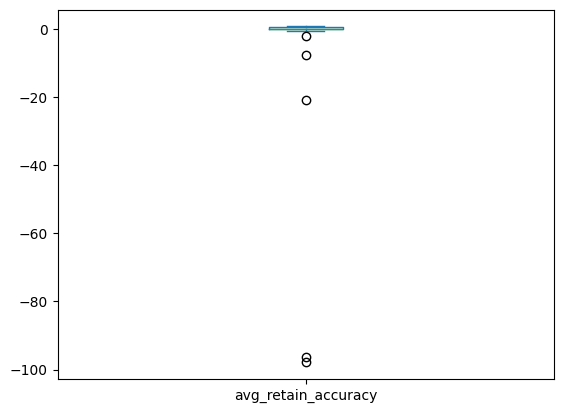

In [ ]:
df[df['stop_threshold'] == 0.1]['avg_retain_accuracy'].plot.box()
# find the highest outliers in the 0.1 set
df[(df['stop_threshold'] == 0.1) & (df['avg_retain_accuracy'] < -50)]

In [ ]:
df[df['stop_threshold'] == 0.9]['avg_retain_accuracy']

1602    0.019719
1604    0.026053
1605    0.005241
1606   -0.004262
1607    0.000356
          ...   
1794   -2.675321
1795    0.009667
1797   -0.056925
1798    0.004098
1799    0.036511
Name: avg_retain_accuracy, Length: 166, dtype: float64

In [ ]:
df.stop_threshold.unique()

array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9])

Let's repeat the above plot with non-relative (non-proportional) metrics

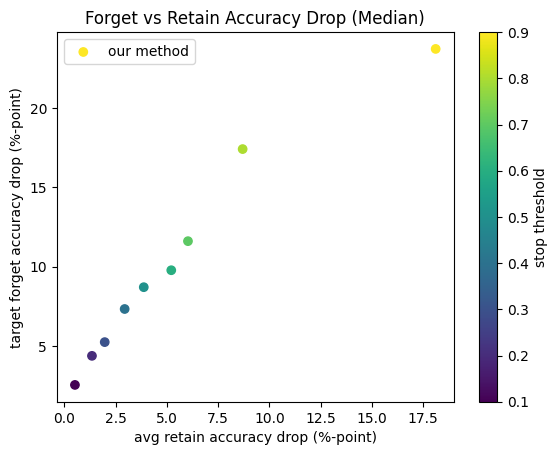

In [ ]:
forget = df.groupby('stop_threshold')['target_difference'].median()
df['retain_acc_drop'] = df.apply(lambda row: np.mean([ast.literal_eval(row['original_accuracy'])[i] - ast.literal_eval(row['accuracy_after'])[i] for i in range(len(ast.literal_eval(row['original_accuracy']))) if i != row['target_class']]), axis=1)
retain = df.groupby('stop_threshold')['retain_acc_drop'].median()

plt.scatter(retain.values * 100, forget.values * 100, c=1-forget.index, label='our method')
plt.xlabel('avg retain accuracy drop (%-point)')
plt.ylabel('target forget accuracy drop (%-point)')
plt.colorbar(label='stop threshold')
plt.title('Forget vs Retain Accuracy Drop (Median)')
plt.legend()

In [ ]:
retain, forget

(stop_threshold
 0.1    0.181176
 0.2    0.086955
 0.3    0.060271
 0.4    0.052120
 0.5    0.038696
 0.6    0.029369
 0.7    0.019640
 0.8    0.013408
 0.9    0.005099
 Name: retain_acc_drop, dtype: float64,
 stop_threshold
 0.1    0.237271
 0.2    0.174134
 0.3    0.116090
 0.4    0.097760
 0.5    0.087067
 0.6    0.073320
 0.7    0.052444
 0.8    0.043788
 0.9    0.025458
 Name: target_difference, dtype: float64)

<Axes: xlabel='steps', ylabel='target_over_overall'>

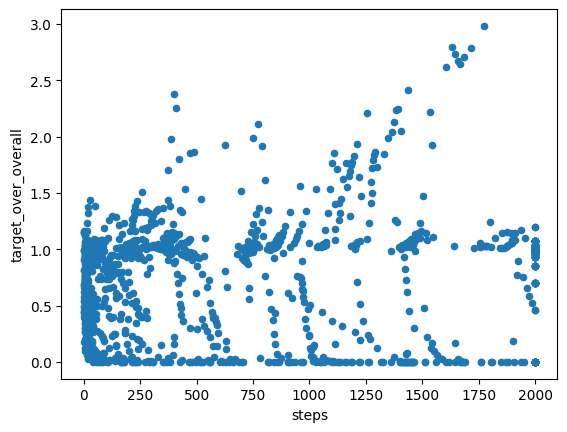

In [ ]:
df.plot.scatter(x='steps', y='target_over_overall')